# Deliverable 4: Proposed Improvement — Multi-scale Context Gating Module (MCGM, P3-only Variant)

**Syed Ibrahim Bin Hassan** (27100201) , **Asad Riaz** (27100055)

**Proposed Modification:** Multi-scale Context Gating Module (MCGM) integrated into YOLOv5s neck (**this v2 notebook applies it to P3 only**)

---

## Pipeline Overview
1. **Dataset Preparation** — Same as Deliverable 3: DOTA v1.5 filtered to 4 classes, 640×640 patches, YOLO HBB format
2. **Model Modification** — MCGM block inserted on the **P3 detect input path only** (instead of P3, P4, and P5)
3. **Training** — Same hyperparameters as baseline (20 epochs, batch 8, img 640) for fair comparison
4. **Evaluation** — mAP@0.5, mAP@0.5:0.95, per-class AP

---

## What Is Different from `deliverable_03_mcgm_v1.ipynb`
1. This notebook tests a **P3-only MCGM integration**.
2. The earlier notebook version targeted **P3 + P4 + P5** paths.
3. Motivation: P3 carries finer spatial detail, so this variant isolates whether a lightweight context gate on small-object features gives better efficiency/accuracy tradeoff.


## 1. Setup and Imports


In [ ]:
!pip install -q ultralytics

import os
import copy
import json
import random
import warnings
import types
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from ultralytics import YOLO
from ultralytics.models.yolo.detect import DetectionTrainer
from ultralytics.nn.tasks import DetectionModel
from ultralytics.utils import LOGGER, RANK


import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import pandas as pd
from tqdm import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
os.environ["WANDB_MODE"] = "disabled"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Torch:", torch.__version__)
print("Ultralytics imported successfully.")


Torch: 2.10.0+cu128
Ultralytics imported successfully.


## 2. Path Configuration


In [20]:
DATASET_ROOT = Path("/kaggle/input/datasets/ishwarghoshrony/dota-dataset")

TRAIN_IMG_DIRS = [
    DATASET_ROOT / "train" / "part1" / "images",
    DATASET_ROOT / "train" / "part2" / "images",
    DATASET_ROOT / "train" / "part3" / "images",
]
TRAIN_ANN_DIR = DATASET_ROOT / "train" / "DOTA-v1.5_train"

# Validation images
VAL_IMG_DIRS = [
    DATASET_ROOT / "valid" / "part1" / "images"
]

# Validation labels (v1.5 only)
VAL_ANN_DIR = Path("/kaggle/input/datasets/ishwarghoshrony/dota-dataset/valid/labelTxt-v1.5_valid-20250901T101921Z-1-001/labelTxt-v1.5/DOTA-v1.5_val")


WORK_DIR = Path("/kaggle/working")
YOLO_DATASET_DIR = WORK_DIR / "dota_yolo"
YOLOV5_DIR = WORK_DIR / "yolov5"

SELECTED_CLASSES = ['plane', 'ship', 'small-vehicle', 'large-vehicle']
CLASS_TO_ID = {cls: i for i, cls in enumerate(SELECTED_CLASSES)}
PATCH_SIZE = 640
PATCH_OVERLAP = 128

print(f"Classes: {SELECTED_CLASSES}")

Classes: ['plane', 'ship', 'small-vehicle', 'large-vehicle']


## 3. DOTA Annotation Parser


In [21]:
def parse_dota_annotation(ann_path):
    objects = []
    with open(ann_path, 'r') as f:
        lines = f.readlines()
    for line in lines:
        line = line.strip()
        if line.startswith('imagesource') or line.startswith('gsd') or len(line) == 0:
            continue
        parts = line.split()
        if len(parts) < 10:
            continue
        try:
            coords = [float(parts[i]) for i in range(8)]
            objects.append({'poly': coords, 'category': parts[8], 'difficulty': int(parts[9])})
        except (ValueError, IndexError):
            continue
    return objects

def obb_to_hbb(poly):
    xs = [poly[0], poly[2], poly[4], poly[6]]
    ys = [poly[1], poly[3], poly[5], poly[7]]
    return [min(xs), min(ys), max(xs), max(ys)]

def hbb_to_yolo(hbb, img_w, img_h):
    xmin, ymin, xmax, ymax = hbb
    return [max(0,min(1,(xmin+xmax)/2/img_w)), max(0,min(1,(ymin+ymax)/2/img_h)),
            max(0,min(1,(xmax-xmin)/img_w)), max(0,min(1,(ymax-ymin)/img_h))]

def find_image_path(stem, img_dirs):
    for d in img_dirs:
        for ext in ['.png','.jpg','.bmp','.tif']:
            p = d / f"{stem}{ext}"
            if p.exists(): return p
    return None

def get_objects_in_patch(objects, x_start, y_start, ps, min_area=20):
    result = []
    for obj in objects:
        hbb = obb_to_hbb(obj['poly'])
        xmin,ymin,xmax,ymax = hbb
        cx = max(xmin,x_start)-x_start; cy = max(ymin,y_start)-y_start
        cx2 = min(xmax,x_start+ps)-x_start; cy2 = min(ymax,y_start+ps)-y_start
        cw,ch = cx2-cx, cy2-cy
        if cw<2 or ch<2: continue
        oa = (xmax-xmin)*(ymax-ymin)
        if oa>0 and (cw*ch)/oa<0.5: continue
        if cw*ch<min_area: continue
        result.append({'hbb':[cx,cy,cx2,cy2],'category':obj['category'],'difficulty':obj['difficulty']})
    return result

def create_patches(img_dirs, ann_dir, out_img, out_lbl, sel_cls, cls2id, ps, ov):
    Path(out_img).mkdir(parents=True, exist_ok=True)
    Path(out_lbl).mkdir(parents=True, exist_ok=True)
    stride = ps - ov
    stats = {'imgs':0,'patches':0,'objects':0,'skip':0}
    for af in tqdm(sorted(Path(ann_dir).glob('*.txt')), desc="Patching"):
        ip = find_image_path(af.stem, img_dirs)
        if ip is None: continue
        objs = [o for o in parse_dota_annotation(af) if o['category'] in sel_cls]
        if not objs: stats['skip']+=1; continue
        img = cv2.imread(str(ip))
        if img is None: continue
        h,w = img.shape[:2]; stats['imgs']+=1
        for ys in range(0,h,stride):
            for xs in range(0,w,stride):
                xe,ye = min(xs+ps,w), min(ys+ps,h)
                xa,ya = max(0,xe-ps), max(0,ye-ps)
                po = get_objects_in_patch(objs, xa, ya, ps)
                if not po: continue
                patch = img[ya:ya+ps, xa:xa+ps]
                ph,pw = patch.shape[:2]
                if ph<ps or pw<ps:
                    pad = np.zeros((ps,ps,3),dtype=np.uint8); pad[:ph,:pw]=patch; patch=pad
                name = f"{af.stem}_{xa}_{ya}"
                cv2.imwrite(str(Path(out_img)/f"{name}.jpg"), patch)
                lines = []
                for o in po:
                    if o['category'] not in cls2id: continue
                    yb = hbb_to_yolo(o['hbb'],ps,ps)
                    if yb[2]<0.002 or yb[3]<0.002: continue
                    lines.append(f"{cls2id[o['category']]} {yb[0]:.6f} {yb[1]:.6f} {yb[2]:.6f} {yb[3]:.6f}")
                if lines:
                    with open(Path(out_lbl)/f"{name}.txt",'w') as f: f.write('\n'.join(lines))
                    stats['patches']+=1; stats['objects']+=len(lines)
    return stats

print("Functions defined.")

Functions defined.


## 4. Image Patching and Subset Creation


In [22]:
train_img_out = YOLO_DATASET_DIR/"images"/"train"
train_lbl_out = YOLO_DATASET_DIR/"labels"/"train"
val_img_out = YOLO_DATASET_DIR/"images"/"val"
val_lbl_out = YOLO_DATASET_DIR/"labels"/"val"

n_train = len(list(train_img_out.glob('*.jpg'))) if train_img_out.exists() else 0
n_val = len(list(val_img_out.glob('*.jpg'))) if val_img_out.exists() else 0

if n_train > 100 and n_val > 100:
    print(f"Dataset exists: {n_train} train, {n_val} val. Skipping.")
else:
    print(f"Found {n_train} train, {n_val} val — recreating both splits...")
    # Clear any partial data
    import shutil
    if YOLO_DATASET_DIR.exists():
        shutil.rmtree(YOLO_DATASET_DIR)

    print("Creating train patches...")
    ts = create_patches(TRAIN_IMG_DIRS, TRAIN_ANN_DIR, train_img_out, train_lbl_out, SELECTED_CLASSES, CLASS_TO_ID, PATCH_SIZE, PATCH_OVERLAP)
    print(f"  {ts['patches']} patches, {ts['objects']} objects")
    print("Creating val patches...")
    vs = create_patches(VAL_IMG_DIRS, VAL_ANN_DIR, val_img_out, val_lbl_out, SELECTED_CLASSES, CLASS_TO_ID, PATCH_SIZE, PATCH_OVERLAP)
    print(f"  {vs['patches']} patches, {vs['objects']} objects")

Dataset exists: 15006 train, 4542 val. Skipping.


## 5. Create Dataset YAML Config


In [23]:
import yaml
dataset_yaml = {'path':str(YOLO_DATASET_DIR),'train':'images/train','val':'images/val',
                'nc':len(SELECTED_CLASSES),'names':SELECTED_CLASSES}
yaml_path = YOLO_DATASET_DIR/'dataset.yaml'
yaml_path.parent.mkdir(parents=True, exist_ok=True)
with open(yaml_path,'w') as f: yaml.dump(dataset_yaml, f, default_flow_style=False)
print(f"YAML: {yaml_path}")

YAML: /kaggle/working/dota_yolo/dataset.yaml


In [ ]:
YOLO_DATASET_DIR = Path("/kaggle/working/dota_yolo")
DATA_YAML = YOLO_DATASET_DIR / "dataset.yaml"

assert DATA_YAML.exists(), f"Dataset YAML not found: {DATA_YAML}"
print("Using dataset YAML:", DATA_YAML)


Using dataset YAML: /kaggle/working/dota_yolo/dataset.yaml


## 6.1 MCGM Module Definition (P3-only)

This is a lightweight residual context block.
It is attached **inside the detect head input path** so it becomes part of the trainer-built model and its parameters are saved in checkpoints. In this v2 notebook, the integration is intentionally restricted to the **P3 branch only**.


In [ ]:
class MCGM(nn.Module):
    """
    P3-friendly MCGM:
    - preserves fine detail with local branch
    - uses multi-scale dilated context
    - uses spatial gate
    - avoids final activation distortion
    - starts residual scale small
    """
    def __init__(self, channels, reduction=4, dilations=(1, 2, 3)):
        super().__init__()
        hidden = max(channels // reduction, 16)

        self.reduce = nn.Sequential(
            nn.Conv2d(channels, hidden, kernel_size=1, bias=False),
            nn.BatchNorm2d(hidden),
            nn.SiLU(inplace=True),
        )

        self.local = nn.Sequential(
            nn.Conv2d(hidden, hidden, kernel_size=1, bias=False),
            nn.BatchNorm2d(hidden),
            nn.SiLU(inplace=True),
        )

        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(hidden, hidden, kernel_size=3, padding=d, dilation=d, bias=False),
                nn.BatchNorm2d(hidden),
                nn.SiLU(inplace=True),
            )
            for d in dilations
        ])

        self.gate = nn.Sequential(
            nn.Conv2d(hidden, hidden, kernel_size=1, bias=True),
            nn.Sigmoid(),
        )

        self.fuse = nn.Sequential(
            nn.Conv2d(hidden * (len(dilations) + 1), channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(channels),
        )

        self.scale = nn.Parameter(torch.tensor(0.01, dtype=torch.float32))

    def forward(self, x):
        z = self.reduce(x)

        gate = self.gate(z)

        local_feat = self.local(z)
        context_feats = [branch(z) * gate for branch in self.branches]

        y = self.fuse(torch.cat([local_feat] + context_feats, dim=1))

        return x + self.scale * y

## 6.2 Detect Head Patching Helpers


In [ ]:
def get_detect_module(model):
    detect = model.model[-1]
    return detect


def infer_detect_in_channels(detect):
    """
    Infer input channels for each detection scale.

    Supports common Ultralytics detect-head layouts.
    """
    ch = []

    if hasattr(detect, "cv2"):
        for branch in detect.cv2:
            m = branch[0]
            if hasattr(m, "conv") and hasattr(m.conv, "in_channels"):
                ch.append(int(m.conv.in_channels))
            elif hasattr(m, "in_channels"):
                ch.append(int(m.in_channels))
            else:
                raise RuntimeError("Could not infer channels from detect.cv2 branch.")
        return ch

    if hasattr(detect, "m"):
        for m in detect.m:
            if hasattr(m, "in_channels"):
                ch.append(int(m.in_channels))
            elif hasattr(m, "conv") and hasattr(m.conv, "in_channels"):
                ch.append(int(m.conv.in_channels))
            else:
                raise RuntimeError("Could not infer channels from detect.m branch.")
        return ch

    raise RuntimeError("Unsupported Detect head layout. Please inspect detect module manually.")


def attach_mcgm_to_detect(model, reduction=4, dilations=(1, 2, 3)):
    """
    Attach MCGM only to P3 Detect input.

    Detect inputs usually map as:
    x[0] = P3, small-object/high-resolution feature map
    x[1] = P4
    x[2] = P5
    """
    detect = get_detect_module(model)

    base_forward = getattr(detect, "_original_forward_mcgm", detect.forward)
    base_forward_fn = base_forward.__func__ if hasattr(base_forward, "__func__") else base_forward
    detect._original_forward_mcgm_fn = base_forward_fn

    in_channels = infer_detect_in_channels(detect)

    # P3 only: MCGM for x[0], Identity for P4/P5
    detect.mcgm_blocks = nn.ModuleList([
        MCGM(c, reduction=reduction, dilations=dilations) if i == 0 else nn.Identity()
        for i, c in enumerate(in_channels)
    ])

    detect.mcgm_scales = ["P3"]

    def forward_with_mcgm(self, x):
        assert isinstance(x, (list, tuple)), f"Detect expected list/tuple of feature maps, got {type(x)}"
        assert len(x) == len(self.mcgm_blocks), (
            f"Feature maps ({len(x)}) and mcgm blocks ({len(self.mcgm_blocks)}) mismatch."
        )

        x_out = []
        for block, feat in zip(self.mcgm_blocks, x):
            p = next(block.parameters(), None)
            if p is not None and (p.device != feat.device or p.dtype != feat.dtype):
                block.to(device=feat.device, dtype=feat.dtype)

            x_out.append(block(feat))

        return self._original_forward_mcgm_fn(self, x_out)

    detect.__class__.forward_with_mcgm = forward_with_mcgm
    detect.forward_with_mcgm = types.MethodType(detect.__class__.forward_with_mcgm, detect)
    detect.forward = detect.forward_with_mcgm

    return model

## 6.3 Custom Trainer

The default detection trainer builds a plain `DetectionModel(cfg, ...)`. We override `get_model()` so the **trainer-built model itself** includes MCGM before optimization starts.


In [27]:

class MCGMTrainer(DetectionTrainer):
    def get_model(self, cfg=None, weights=None, verbose=True):
        """
        Build the actual trainable model used by the trainer.
        """
        model = DetectionModel(
            cfg,
            nc=self.data["nc"],
            ch=self.data["channels"],
            verbose=verbose and RANK == -1
        )

        attach_mcgm_to_detect(model, reduction=4, dilations=(1, 2, 3))

        if weights is not None:
            model.load(weights)

        return model


## 7.1 Pre-training Verification

This checks that MCGM is really inside the trainer model **before** training.


In [ ]:

base_model = YOLO("yolov5s.pt")

trainer_args = {
    "model": "yolov5s.pt",
    "data": str(DATA_YAML),
    "imgsz": 640,
    "epochs": 1, 
    "batch": 8,
    "workers": 2,
    "project": "/kaggle/working/runs",
    "name": "yolov5s_mcgm",
    "seed": SEED,
    "cache": False,
    "device": 0 if torch.cuda.is_available() else "cpu",
    "verbose": True,
    "amp": False,
}

trainer = MCGMTrainer(overrides=trainer_args, _callbacks=base_model.callbacks)
trainer.data = trainer.get_dataset()

# Build the exact model the trainer will optimize
trainer.model = trainer.get_model(weights=base_model.model, cfg=base_model.model.yaml)

mcgm_param_names = [n for n, _ in trainer.model.named_parameters() if "mcgm" in n.lower()]
print("Number of MCGM parameter tensors:", len(mcgm_param_names))
print("Sample MCGM params:", mcgm_param_names[:12])

assert len(mcgm_param_names) > 0, "MCGM params not found in trainer model."

detect = trainer.model.model[-1]
assert hasattr(detect, "mcgm_blocks"), "Detect head does not contain mcgm_blocks."

# Optional dry-run
trainer.model.eval()
with torch.no_grad():
    dummy = torch.randn(1, 3, 640, 640, device=next(trainer.model.parameters()).device)
    _ = trainer.model(dummy)

print("Trainer-side model verification passed.")


PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

Ultralytics 8.4.43 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dota_yolo/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=

## 7.2 Training


In [ ]:
model = YOLO("yolov5s.pt")

results = model.train(
    data=str(DATA_YAML),
    imgsz=640,
    epochs=20, 
    batch=8,
    workers=2,
    project="/kaggle/working/runs",
    name="yolov5s_mcgm",
    seed=SEED,
    cache=False,
    amp=False,
    device=0 if torch.cuda.is_available() else "cpu",
    trainer=MCGMTrainer,
)
print("Training finished.")


PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

Ultralytics 8.4.43 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dota_yolo/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj

## 7.3 Post-training Verification

This is the proof that the saved checkpoint actually contains MCGM weights.
If this list is empty, your custom block was not trained/saved correctly.


In [ ]:
RUN_DIR = Path("/kaggle/working/runs/yolov5s_mcgm-6")
BEST_WEIGHTS = RUN_DIR / "weights" / "best.pt"
LAST_WEIGHTS = RUN_DIR / "weights" / "last.pt"

print("best exists:", BEST_WEIGHTS.exists(), BEST_WEIGHTS)
print("last exists:", LAST_WEIGHTS.exists(), LAST_WEIGHTS)

ckpt_path = BEST_WEIGHTS if BEST_WEIGHTS.exists() else LAST_WEIGHTS
assert ckpt_path.exists(), f"No checkpoint found in {RUN_DIR}"

ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
state_dict = None

if isinstance(ckpt, dict):
    if "model" in ckpt and hasattr(ckpt["model"], "state_dict"):
        state_dict = ckpt["model"].state_dict()
    elif "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]
else:
    raise RuntimeError("Unexpected checkpoint format.")

mcgm_keys = [k for k in state_dict.keys() if "mcgm" in k.lower()]
print("MCGM keys in checkpoint:", len(mcgm_keys))
print("Sample checkpoint keys:", mcgm_keys[:20])

assert len(mcgm_keys) > 0, "Checkpoint does not contain MCGM weights."
print("Checkpoint verification passed.")


best exists: True /kaggle/working/runs/yolov5s_mcgm-6/weights/best.pt
last exists: True /kaggle/working/runs/yolov5s_mcgm-6/weights/last.pt
MCGM keys in checkpoint: 39
Sample checkpoint keys: ['model.24.mcgm_blocks.0.scale', 'model.24.mcgm_blocks.0.reduce.0.weight', 'model.24.mcgm_blocks.0.reduce.1.weight', 'model.24.mcgm_blocks.0.reduce.1.bias', 'model.24.mcgm_blocks.0.reduce.1.running_mean', 'model.24.mcgm_blocks.0.reduce.1.running_var', 'model.24.mcgm_blocks.0.reduce.1.num_batches_tracked', 'model.24.mcgm_blocks.0.local.0.weight', 'model.24.mcgm_blocks.0.local.1.weight', 'model.24.mcgm_blocks.0.local.1.bias', 'model.24.mcgm_blocks.0.local.1.running_mean', 'model.24.mcgm_blocks.0.local.1.running_var', 'model.24.mcgm_blocks.0.local.1.num_batches_tracked', 'model.24.mcgm_blocks.0.branches.0.0.weight', 'model.24.mcgm_blocks.0.branches.0.1.weight', 'model.24.mcgm_blocks.0.branches.0.1.bias', 'model.24.mcgm_blocks.0.branches.0.1.running_mean', 'model.24.mcgm_blocks.0.branches.0.1.running_

## 8. Reload Trained MCGM Model for Inference/Validation

This reconstructs the same architecture and then loads the saved checkpoint.
Use this instead of attaching MCGM after the fact to a plain trained model.


In [ ]:
def build_mcgm_detection_model_from_base(base_weights="yolov5s.pt", nc=4, ch=3):
    base = YOLO(base_weights)
    model = DetectionModel(base.model.yaml, nc=nc, ch=ch, verbose=True)
    attach_mcgm_to_detect(model, reduction=4, dilations=(1, 2, 3))
    return model


def load_trained_mcgm_checkpoint(ckpt_path, base_weights="yolov5s.pt", nc=4, ch=3, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = build_mcgm_detection_model_from_base(base_weights=base_weights, nc=nc, ch=ch).to(device)

    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

    if "model" in ckpt and hasattr(ckpt["model"], "state_dict"):
        sd = ckpt["model"].state_dict()
    elif "state_dict" in ckpt:
        sd = ckpt["state_dict"]
    else:
        raise RuntimeError("Unexpected checkpoint format.")

    missing, unexpected = model.load_state_dict(sd, strict=False)
    print("Missing keys:", len(missing))
    print("Unexpected keys:", len(unexpected))
    print("Sample missing:", missing[:10])
    print("Sample unexpected:", unexpected[:10])
    return model.eval()


with open(DATA_YAML, "r") as f:
    dataset_info = __import__("yaml").safe_load(f)

trained_mcgm_model = load_trained_mcgm_checkpoint(
    ckpt_path,
    base_weights="yolov5s.pt",
    nc=int(dataset_info["nc"]),
    ch=3,
)
print("Reloaded trained MCGM model.")


PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1      3520  ultralytics.nn.modules.conv.Conv             [3, 32, 6, 2, 2]              
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     18816  ultralytics.nn.modules.block.C3              [64, 64, 1]                   
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    115712  ultralytics.nn.modules.block.C3              [128, 128, 2]                 
  5                 

## 9. MCGM Evaluation and Analysis

These cells replicate your baseline analysis workflow but target the latest MCGM run (`yolov5s_mcgm*`).


In [33]:
print('=' * 60)
print('MCGM: YOLOv5s + MCGM Evaluation')
print('=' * 60)

RUNS_ROOT = Path('/kaggle/working/runs')
mcgm_runs = sorted(RUNS_ROOT.glob('yolov5s_mcgm*'), key=lambda p: p.stat().st_mtime, reverse=True)
assert mcgm_runs, 'No yolov5s_mcgm* run directories found.'

MCGM_RUN_DIR = mcgm_runs[0]
MCGM_BEST = MCGM_RUN_DIR / 'weights' / 'best.pt'
assert MCGM_BEST.exists(), f'MCGM best.pt not found: {MCGM_BEST}'

IMG_SIZE = globals().get('IMG_SIZE', 640)
BATCH_SIZE = globals().get('BATCH_SIZE', 8)

print('Using run dir:', MCGM_RUN_DIR)
print('Using weights:', MCGM_BEST)

mcgm_eval = YOLO(str(MCGM_BEST))
mcgm_eval_metrics = mcgm_eval.val(
    data=str(DATA_YAML),
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    split='val',
    project='/kaggle/working/runs',
    name='yolov5s_mcgm_eval',
    exist_ok=True,
    verbose=True,
)
print(mcgm_eval_metrics.results_dict)


MCGM: YOLOv5s + MCGM Evaluation
Using run dir: /kaggle/working/runs/yolov5s_mcgm-6
Using weights: /kaggle/working/runs/yolov5s_mcgm-6/weights/best.pt
Ultralytics 8.4.43 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv5s summary (fused): 106 layers, 9,163,869 parameters, 0 gradients, 24.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2388.8±342.6 MB/s, size: 143.2 KB)
val: Scanning /kaggle/working/dota_yolo/labels/val.cache... 4542 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4542/4542 1.1Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 568/568 8.4it/s 1:07<0.1ss
                   all       4542     108874      0.875      0.817      0.871      0.604
                 plane       1012       4425      0.914      0.924      0.962      0.739
                  ship       1358      20641      0.932      0.899      0.951      0.679
         small-vehicle       2738      72995       0.82

## 10. Training Curves


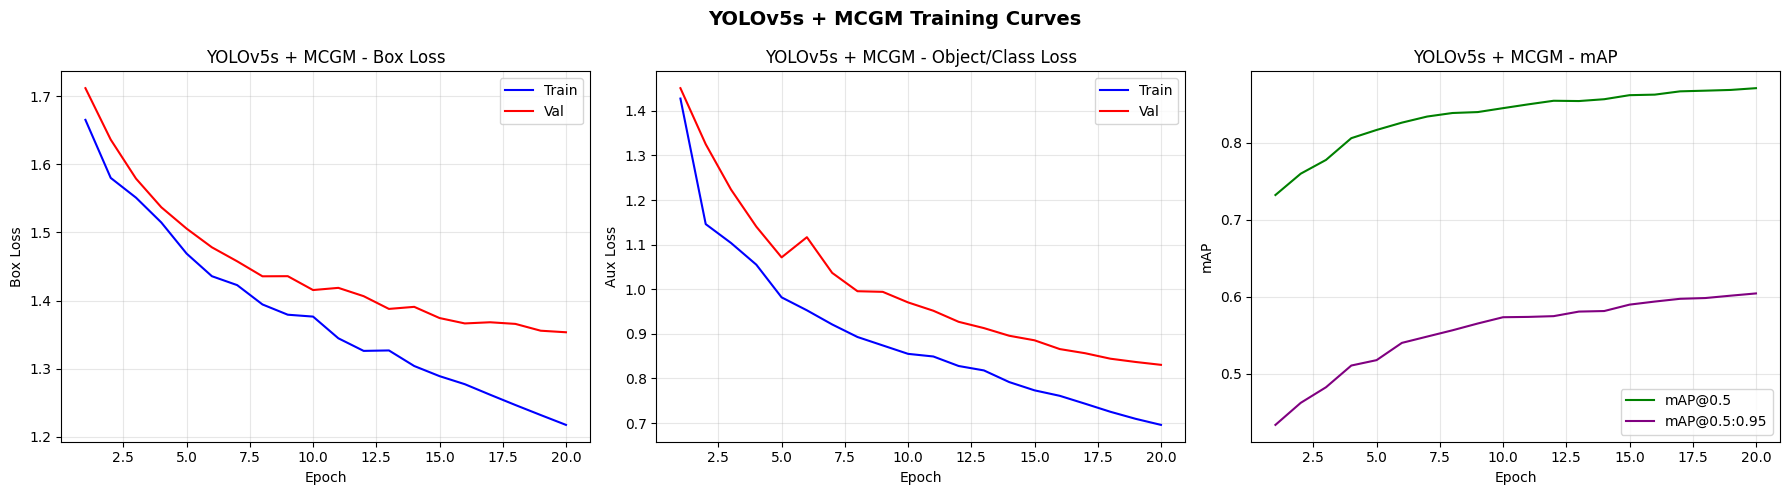

 YOLOv5s + MCGM Best Results (Epoch 20):
  mAP@0.5:      0.8708
  mAP@0.5:0.95: 0.6043
  Precision:    0.8747
  Recall:       0.8173


In [ ]:
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def plot_training_curves(results_csv_path, model_name):
    """Plot loss and mAP curves from training results.csv"""
    df = pd.read_csv(results_csv_path)
    df.columns = df.columns.str.strip()

    epoch_col = pick_col(df, ['epoch'])
    box_train_col = pick_col(df, ['train/box_loss'])
    box_val_col = pick_col(df, ['val/box_loss'])
    aux_train_col = pick_col(df, ['train/obj_loss', 'train/cls_loss'])
    aux_val_col = pick_col(df, ['val/obj_loss', 'val/cls_loss'])
    map50_col = pick_col(df, ['metrics/mAP_0.5', 'metrics/mAP50(B)'])
    map5095_col = pick_col(df, ['metrics/mAP_0.5:0.95', 'metrics/mAP50-95(B)'])
    prec_col = pick_col(df, ['metrics/precision', 'metrics/precision(B)'])
    rec_col = pick_col(df, ['metrics/recall', 'metrics/recall(B)'])

    if epoch_col is None or map50_col is None:
        print(f'Could not parse expected metric columns in {results_csv_path}')
        print('Available columns:', list(df.columns))
        return

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    if box_train_col and box_val_col:
        axes[0].plot(df[epoch_col], df[box_train_col], label='Train', color='blue')
        axes[0].plot(df[epoch_col], df[box_val_col], label='Val', color='red')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Box Loss')
    axes[0].set_title(f'{model_name} - Box Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    if aux_train_col and aux_val_col:
        axes[1].plot(df[epoch_col], df[aux_train_col], label='Train', color='blue')
        axes[1].plot(df[epoch_col], df[aux_val_col], label='Val', color='red')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Aux Loss')
    axes[1].set_title(f'{model_name} - Object/Class Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(df[epoch_col], df[map50_col], label='mAP@0.5', color='green')
    if map5095_col:
        axes[2].plot(df[epoch_col], df[map5095_col], label='mAP@0.5:0.95', color='purple')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('mAP')
    axes[2].set_title(f'{model_name} - mAP')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(f'{model_name} Training Curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    best_epoch = df[map50_col].idxmax()
    print(f" {model_name} Best Results (Epoch {int(df.loc[best_epoch, epoch_col])}):")
    print(f"  mAP@0.5:      {df.loc[best_epoch, map50_col]:.4f}")
    if map5095_col:
        print(f"  mAP@0.5:0.95: {df.loc[best_epoch, map5095_col]:.4f}")
    if prec_col:
        print(f"  Precision:    {df.loc[best_epoch, prec_col]:.4f}")
    if rec_col:
        print(f"  Recall:       {df.loc[best_epoch, rec_col]:.4f}")


mcgm_results = MCGM_RUN_DIR / 'results.csv'

if mcgm_results.exists():
    plot_training_curves(mcgm_results, 'YOLOv5s + MCGM')
else:
    print(f'MCGM results.csv not found: {mcgm_results}')


## 11. YOLOv5 + MCGM Metrics Summary


In [35]:
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def get_best_metrics(results_csv_path):
    """Extract best metrics from results.csv"""
    df = pd.read_csv(results_csv_path)
    df.columns = df.columns.str.strip()

    map50_col = pick_col(df, ['metrics/mAP_0.5', 'metrics/mAP50(B)'])
    map5095_col = pick_col(df, ['metrics/mAP_0.5:0.95', 'metrics/mAP50-95(B)'])
    prec_col = pick_col(df, ['metrics/precision', 'metrics/precision(B)'])
    rec_col = pick_col(df, ['metrics/recall', 'metrics/recall(B)'])
    epoch_col = pick_col(df, ['epoch'])

    best_idx = df[map50_col].idxmax()
    out = {
        'mAP@0.5': df.loc[best_idx, map50_col],
        'Best Epoch': int(df.loc[best_idx, epoch_col]),
    }
    if map5095_col:
        out['mAP@0.5:0.95'] = df.loc[best_idx, map5095_col]
    if prec_col:
        out['Precision'] = df.loc[best_idx, prec_col]
    if rec_col:
        out['Recall'] = df.loc[best_idx, rec_col]
    return out


if mcgm_results.exists():
    metrics = get_best_metrics(mcgm_results)
    print('YOLOv5s + MCGM Summary')
    print('=' * 50)
    print(f"Best Epoch:   {metrics['Best Epoch']}")
    print(f"mAP@0.5:      {metrics['mAP@0.5']:.4f}")
    if 'mAP@0.5:0.95' in metrics:
        print(f"mAP@0.5:0.95: {metrics['mAP@0.5:0.95']:.4f}")
    if 'Precision' in metrics:
        print(f"Precision:    {metrics['Precision']:.4f}")
    if 'Recall' in metrics:
        print(f"Recall:       {metrics['Recall']:.4f}")
else:
    print('MCGM results.csv not found. Check training output.')


YOLOv5s + MCGM Summary
Best Epoch:   20
mAP@0.5:      0.8708
mAP@0.5:0.95: 0.6043
Precision:    0.8747
Recall:       0.8173


## 12. Inference Visualization


In [ ]:
import shutil

# Get some validation images
val_images = sorted((YOLO_DATASET_DIR / 'images' / 'val').glob('*.jpg'))
sample_val = random.sample(val_images, min(8, len(val_images)))

# Create a temporary directory with sample images
sample_dir = WORK_DIR / 'sample_inference_mcgm'
sample_dir.mkdir(exist_ok=True)
for img in sample_val:
    shutil.copy(img, sample_dir / img.name)

# Run MCGM inference
mcgm_infer = YOLO(str(MCGM_BEST))
mcgm_infer.predict(
    source=str(sample_dir),
    imgsz=IMG_SIZE,
    conf=0.25,
    project='/kaggle/working/runs',
    name='yolov5s_mcgm_inference',
    exist_ok=True,
    save=True,
    save_txt=True,
    save_conf=True,
)


image 1/8 /kaggle/working/sample_inference_mcgm/P0161_1536_2074.jpg: 640x640 299 small-vehicles, 1 large-vehicle, 15.5ms
image 2/8 /kaggle/working/sample_inference_mcgm/P1179_2560_4096.jpg: 640x640 3 planes, 3 small-vehicles, 1 large-vehicle, 15.5ms
image 3/8 /kaggle/working/sample_inference_mcgm/P1283_2560_3072.jpg: 640x640 (no detections), 15.4ms
image 4/8 /kaggle/working/sample_inference_mcgm/P1314_3360_2560.jpg: 640x640 9 ships, 15.4ms
image 5/8 /kaggle/working/sample_inference_mcgm/P1376_3072_512.jpg: 640x640 10 small-vehicles, 15.5ms
image 6/8 /kaggle/working/sample_inference_mcgm/P2231_1024_512.jpg: 640x640 2 planes, 50 small-vehicles, 15.4ms
image 7/8 /kaggle/working/sample_inference_mcgm/P2754_1536_2048.jpg: 640x640 18 small-vehicles, 1 large-vehicle, 15.1ms
image 8/8 /kaggle/working/sample_inference_mcgm/P2802_2048_3584.jpg: 640x640 1 plane, 2 small-vehicles, 5 large-vehicles, 13.4ms
Speed: 1.9ms preprocess, 15.1ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'plane', 1: 'ship', 2: 'small-vehicle', 3: 'large-vehicle'}
 obb: None
 orig_img: array([[[ 84,  78,  79],
         [ 90,  84,  85],
         [ 89,  83,  84],
         ...,
         [115, 123, 130],
         [173, 179, 184],
         [161, 167, 172]],
 
        [[ 85,  79,  80],
         [ 86,  80,  81],
         [ 88,  82,  83],
         ...,
         [102, 110, 117],
         [111, 117, 122],
         [126, 132, 137]],
 
        [[ 87,  82,  83],
         [ 83,  78,  79],
         [ 88,  82,  83],
         ...,
         [144, 152, 159],
         [ 91,  97, 104],
         [ 90,  96, 103]],
 
        ...,
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
        

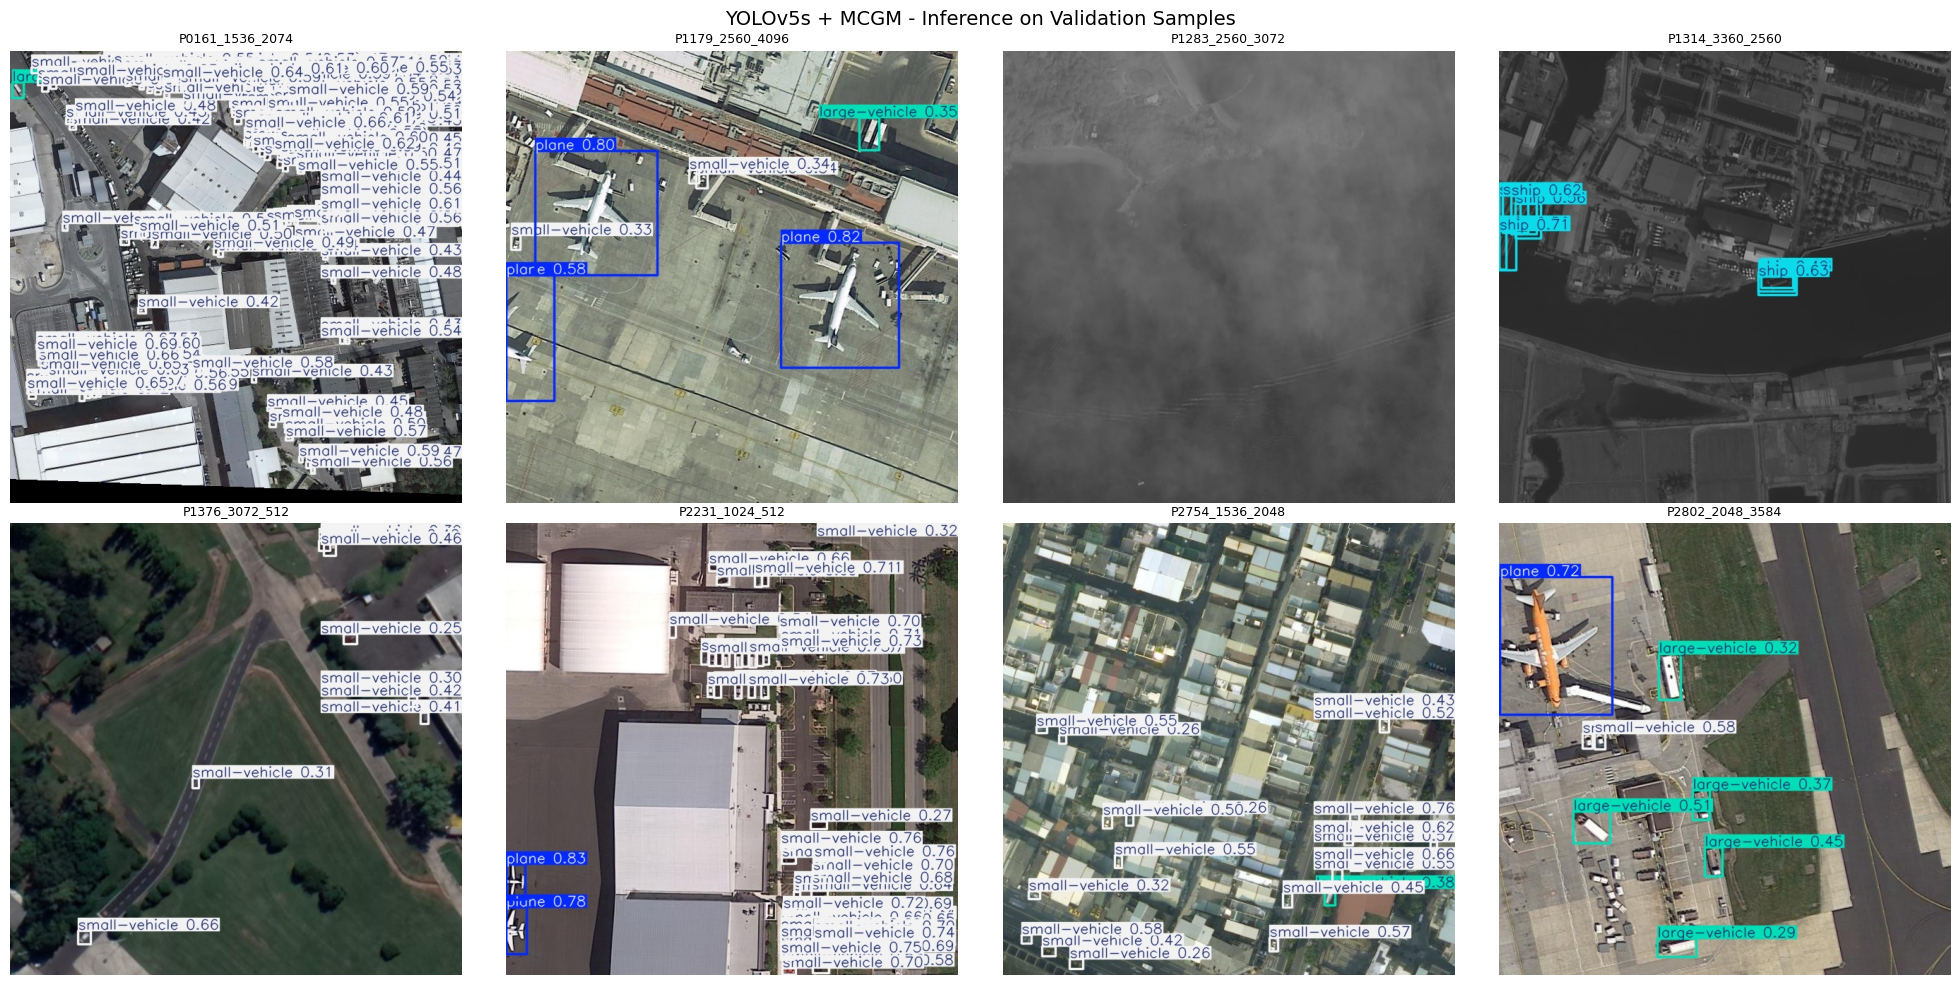

In [ ]:
inference_dir = Path('/kaggle/working/runs/yolov5s_mcgm_inference')
inference_images = sorted(inference_dir.glob('*.jpg'))

if len(inference_images) > 0:
    n_show = min(8, len(inference_images))
    cols = 4
    rows = (n_show + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    axes = axes.flatten() if n_show > 1 else [axes]

    for idx, img_path in enumerate(inference_images[:n_show]):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(img)
        axes[idx].set_title(img_path.stem, fontsize=9)
        axes[idx].axis('off')

    for idx in range(n_show, len(axes)):
        axes[idx].axis('off')

    plt.suptitle('YOLOv5s + MCGM - Inference on Validation Samples', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('No inference images found. Check detection output.')


## 13. YOLOv5 + MCGM: Generated Evaluation Plots


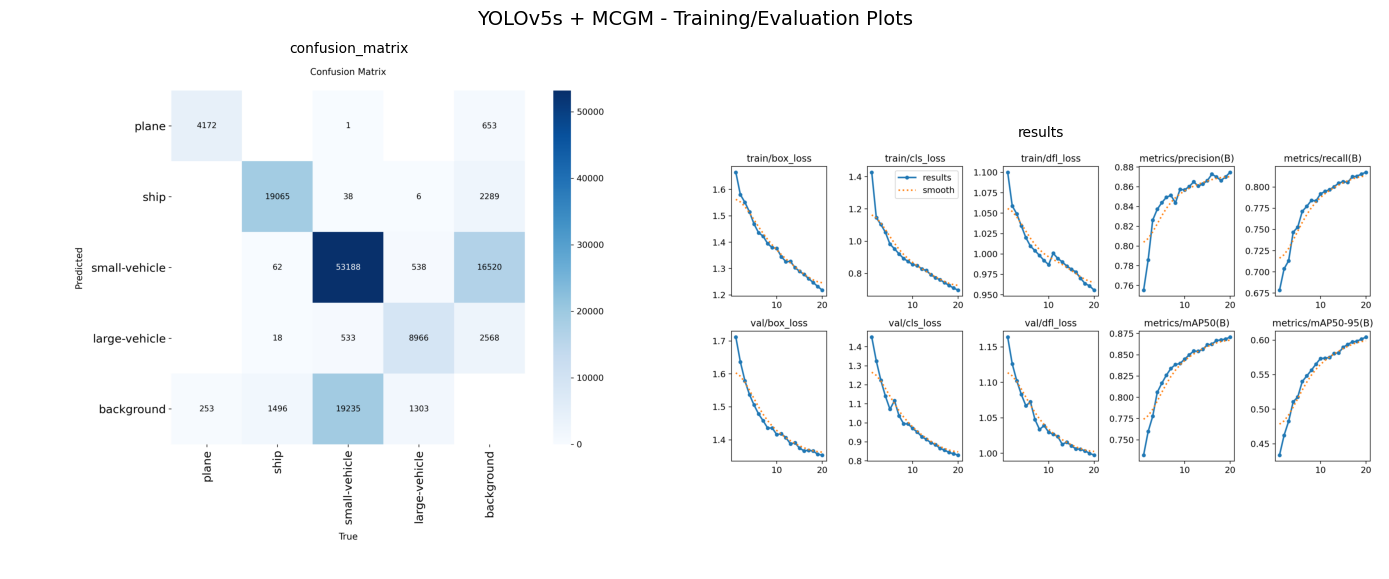

In [38]:
plot_names = ['confusion_matrix.png', 'F1_curve.png', 'P_curve.png',
              'R_curve.png', 'PR_curve.png', 'results.png']

for model_name, run_path in [('YOLOv5s + MCGM', MCGM_RUN_DIR)]:
    available_plots = [run_path / p for p in plot_names if (run_path / p).exists()]

    if available_plots:
        n_plots = len(available_plots)
        cols = min(3, n_plots)
        rows = (n_plots + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 6 * rows))
        if n_plots == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        for idx, plot_path in enumerate(available_plots):
            img = cv2.imread(str(plot_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[idx].imshow(img)
            axes[idx].set_title(plot_path.stem, fontsize=10)
            axes[idx].axis('off')

        for idx in range(n_plots, len(axes)):
            axes[idx].axis('off')

        plt.suptitle(f'{model_name} - Training/Evaluation Plots', fontsize=14)
        plt.tight_layout()
        plt.show()
    else:
        print(f'No plots found for {model_name} at {run_path}')


## 14. Model Complexity Comparison


In [ ]:
def get_model_info(weights_path):
    """Get model parameter count and file size."""
    ckpt = torch.load(weights_path, map_location='cpu', weights_only=False)
    model = ckpt.get('model', ckpt.get('ema', None))

    if model is not None and hasattr(model, 'parameters'):
        n_params = sum(p.numel() for p in model.parameters())
    else:
        n_params = 0

    file_size_mb = os.path.getsize(weights_path) / (1024 * 1024)
    return n_params, file_size_mb


print('Model Complexity Summary')
print('=' * 55)
print(f"{'Model':<20} {'Parameters':>15} {'Weight File':>15}")
print('-' * 55)

weights = MCGM_BEST
if weights.exists():
    n_params, size_mb = get_model_info(weights)
    print(f"{'YOLOv5s + MCGM':<20} {n_params:>12,} p {size_mb:>12.1f} MB")
else:
    print(f"{'YOLOv5s + MCGM':<20} {'weights not found':>30}")


Model Complexity Summary
Model                     Parameters     Weight File
-------------------------------------------------------
YOLOv5s + MCGM          9,174,525 p         17.8 MB
